# Benchmark — Barrido Matryoshka (P6): efectividad vs. eficiencia

**Proyecto:** Buscador semántico híbrido (GovTech / SUID). **Notebook:** análisis de la
pregunta P6. Todo el código está **inline** (encoder, BM25, índice denso, RRF, métricas);
recomputa el barrido de dimensión en vivo.

## 1. Contexto

### 1.1 El problema

El índice denso guarda un vector por documento; su tamaño y el costo de la búsqueda crecen
con la **dimensión** del embedding (1024 en `jina-embeddings-v3`). ¿Se puede reducir esa
dimensión sin perder calidad?

### 1.2 Matryoshka (MRL)

`jina-embeddings-v3` está entrenado con *Matryoshka Representation Learning*: los primeros
`m` componentes de cada vector siguen siendo una representación válida. Se puede **truncar**
1024 → 768/512/256/128 sin reentrenar, renormalizando. Es una operación **determinista**
sobre el vector ya calculado (el modelo sigue congelado; no hay entrenamiento).

### 1.3 Objetivo (P6)

Encontrar el mejor equilibrio **efectividad / latencia / memoria**. Se barre la mejor
configuración desplegable (Híbrido + ontología, peldaño 4) y, como referencia, el **Denso
puro** (peldaño 1), que es el más sensible a `m`.

## 2. Preparación del entorno

**Descripción Técnica.** Librerías, rutas, configuración y datos ya construidos.

In [1]:
import json, sys, time, math, re, unicodedata
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml

RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
EXP = RAIZ / "experimentos"
cfg = yaml.safe_load((EXP / "config.yaml").read_text(encoding="utf-8"))
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

def cargar_jsonl(r): return [json.loads(l) for l in (EXP/r).read_text(encoding="utf-8").splitlines() if l.strip()]
docs = cargar_jsonl(cfg["rutas"]["corpus"])
consultas = cargar_jsonl(cfg["rutas"]["consultas"])
qrels = {r["id"]: r["relevancia"] for r in cargar_jsonl(cfg["rutas"]["qrels"])}
ontologia = yaml.safe_load((EXP / cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))
tiene_gold = lambda q: any(g>0 for g in q.values())
con_gold = [c for c in consultas if tiene_gold(qrels.get(c["id"],{}))]
DIMS = cfg["matryoshka"]["dims"]
print("Modelo:", cfg["encoder"]["modelo_st"], "| consultas con gold:", len(con_gold), "| dims:", DIMS)

Modelo: jinaai/jina-embeddings-v3 | consultas con gold: 40 | dims: [128, 256, 512, 768, 1536]


## 3. Metodología: componentes inline

**Contexto y Objetivo.** Reunir el código mínimo (métricas, BM25, índice denso, RRF,
detector y motor) para que el notebook sea autónomo.

**Descripción Técnica.** Idéntico al del notebook de la escalera; el motor solo expone las
dos configuraciones necesarias (1 y 4).

In [2]:
# métricas
def _g(q,d): return float(q.get(d,0.0))
def dcg(r,q,k): return sum((2.0**_g(q,d)-1)/math.log2(i+1) for i,d in enumerate(r[:k],1) if _g(q,d)>0)
def ndcg(r,q,k):
    ideal=sorted((g for g in q.values() if g>0),reverse=True)
    idcg=sum((2.0**g-1)/math.log2(i+1) for i,g in enumerate(ideal[:k],1))
    return 0.0 if idcg==0 else dcg(r,q,k)/idcg
def mrr(r,q,k):
    for i,d in enumerate(r[:k],1):
        if _g(q,d)>0: return 1.0/i
    return 0.0
# tokenizador + BM25
_STOP={"el","la","los","las","un","una","unos","unas","de","del","a","ante","con","en","para","por",
       "que","y","o","u","se","su","sus","lo","al","es","son","como","mas","pero","sin","sobre","entre",
       "cada","ya","cuando","donde","cual","quien","cuanto","muy","este","esta","estos"}
def tok(t):
    t=unicodedata.normalize("NFKD",t.lower()); t="".join(c for c in t if not unicodedata.combining(c))
    return [x for x in re.findall(r"[a-z0-9]+",t) if x not in _STOP and len(x)>1]
class BM25Index:
    def __init__(self,k1=1.5,b=0.75): self.k1,self.b=k1,b
    def indexar(self,ids,textos):
        self._ids=list(ids); self._tf=[Counter(tok(t)) for t in textos]
        self._len=[sum(c.values()) for c in self._tf]; self._avg=(sum(self._len)/len(self._len)) if self._len else 0.0
        df=Counter()
        for c in self._tf: df.update(c.keys())
        n=len(self._tf); self._idf={t:math.log(1+(n-d+0.5)/(d+0.5)) for t,d in df.items()}; return self
    def buscar(self,q):
        qt=tok(q); s=np.zeros(len(self._ids))
        for i,tf in enumerate(self._tf):
            acc=0.0
            for t in qt:
                if t in tf:
                    f=tf[t]; den=f+self.k1*(1-self.b+self.b*self._len[i]/(self._avg or 1))
                    acc+=self._idf.get(t,0.0)*f*(self.k1+1)/den
            s[i]=acc
        return [(self._ids[i],float(s[i])) for i in np.argsort(-s)]
# denso
def _l2(m):
    n=np.linalg.norm(m,axis=1,keepdims=True); n[n==0]=1.0; return m/n
class DenseIndex:
    def __init__(self,enc): self.enc=enc
    def indexar(self,ids,textos): self._ids=list(ids); self._mat=self.enc.encode(textos); return self
    def buscar(self,q):
        qv=self.enc.encode([q])[0]; s=self._mat@qv
        return [(self._ids[i],float(s[i])) for i in np.argsort(-s)]
# RRF + detector + motor
def _norm(s):
    s=unicodedata.normalize("NFKD",s.lower()); return "".join(c for c in s if not unicodedata.combining(c))
def rrf(a,b,k=60):
    ra={d:i+1 for i,(d,_) in enumerate(a)}; rb={d:i+1 for i,(d,_) in enumerate(b)}
    ds=[d for d,_ in a]+[d for d,_ in b if d not in ra]; big=len(ds)+k+1
    fus={d:1.0/(k+ra.get(d,big))+1.0/(k+rb.get(d,big)) for d in ds}
    return sorted(ds,key=lambda d:(-fus[d],d)), fus
class DetectorEntidades:
    def __init__(self,onto):
        self._t=[]
        for cl,cu in onto.get("clases",{}).items():
            for x in [cl,*cu.get("sinonimos",[])]: self._t.append((_norm(x),cl))
        self._p=re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases_en(self,q):
        cq=_norm(q); return {c for t,c in self._t if t and t in cq}
    def nombre_propio(self,q):
        toks=self._p.findall(q)
        if not toks: return False
        pr=q.strip().split()[:1]; cand=[t for t in toks if not (pr and t==pr[0])]
        return any(_norm(t) not in {tt for tt,_ in self._t} for t in cand)
class Motor:
    def __init__(self,docs,enc,onto,k1,b,k_rrf,lam):
        self.ids=[d["id"] for d in docs]; self.k=k_rrf; self.lam=lam; self.det=DetectorEntidades(onto)
        self.ent={d["id"]:set(d["metadatos_ontologia"].get("entidades_principales",[])) for d in docs}
        self.np={d["id"]:bool(d.get("nombre_propio_buscable",False)) for d in docs}
        desc=[d["descripcion"] for d in docs]; ot=[d["texto_indexable"] for d in docs]
        self.bd=BM25Index(k1,b).indexar(self.ids,desc); self.bo=BM25Index(k1,b).indexar(self.ids,ot)
        self.dd=DenseIndex(enc).indexar(self.ids,desc); self.do=DenseIndex(enc).indexar(self.ids,ot)
    def recuperar(self,cfg_num,q):
        if cfg_num==1: return [d for d,_ in self.dd.buscar(q)]
        if cfg_num==4: return rrf(self.bo.buscar(q), self.do.buscar(q), self.k)[0]
        raise ValueError(cfg_num)
print("Código inline listo.")

Código inline listo.


## 4. Codificador base cacheado y truncación MRL

**Contexto y Objetivo.** Evitar recodificar por cada dimensión.

**Descripción Técnica.** Se carga el modelo real **una vez** (con el shim de
`transformers` 5.x) y se cachean los vectores full-dim por texto; cada `m` solo trunca y
renormaliza.

In [3]:
class STBase:
    def __init__(self, modelo):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel,"all_tied_weights_keys"): PreTrainedModel.all_tied_weights_keys = {}
        from sentence_transformers import SentenceTransformer
        self.m = SentenceTransformer(modelo, trust_remote_code=True)
        self.dim = self.m.get_sentence_embedding_dimension(); self.nombre = modelo.split("/")[-1]
    def encode_full(self, textos):
        return self.m.encode(list(textos), convert_to_numpy=True, normalize_embeddings=False).astype(np.float32)
class Cache:
    def __init__(self, base): self.base=base; self.c={}
    def full(self, textos):
        faltan=[t for t in textos if t not in self.c]
        if faltan:
            for t,v in zip(faltan, self.base.encode_full(faltan)): self.c[t]=v
        return np.vstack([self.c[t] for t in textos])
class TruncEncoder:
    def __init__(self, cache, m): self.cache=cache; self.m=m; self.dim=m; self.nombre=f"mrl{m}"
    def encode(self, textos): return _l2(self.cache.full(list(textos))[:, :self.m])

base = STBase(cfg["encoder"]["modelo_st"])
DIM_FULL = base.dim
DIMS = sorted({min(d, DIM_FULL) for d in DIMS} | {DIM_FULL})
cache = Cache(base)
_ = cache.full([d["descripcion"] for d in docs] + [d["texto_indexable"] for d in docs] + [c["texto"] for c in consultas])
print("Modelo:", base.nombre, "| dim completa:", DIM_FULL, "| dims a evaluar:", DIMS, "| textos cacheados:", len(cache.c))

Modelo: jina-embeddings-v3 | dim completa: 1024 | dims a evaluar: [128, 256, 512, 768, 1024] | textos cacheados: 77


## 5. Barrido de dimensión

**Descripción Técnica.** Para cada `m` se reconstruye el índice truncado y se evalúan las
configuraciones 1 y 4 sobre las consultas con gold, midiendo nDCG@10, MRR@10, latencia y
tamaño del índice.

In [4]:
def evalua(cfg_num, enc, reps=3):
    mot = Motor(docs, enc, ontologia, cfg["bm25"]["k1"], cfg["bm25"]["b"], cfg["fusion"]["k_rrf"], cfg["realce"]["lambda"])
    nd, mr, lat = [], [], []
    for c in con_gold:
        best=np.inf; rank=None
        for _ in range(reps):
            t0=time.perf_counter(); rank=mot.recuperar(cfg_num, c["texto"]); best=min(best,(time.perf_counter()-t0)*1000)
        nd.append(ndcg(rank, qrels[c["id"]],10)); mr.append(mrr(rank, qrels[c["id"]],10)); lat.append(best)
    return dict(ndcg=float(np.mean(nd)), mrr=float(np.mean(mr)), lat50=float(np.percentile(lat,50)))

filas=[]
for m in DIMS:
    enc=TruncEncoder(cache,m); r1=evalua(1,enc); r4=evalua(4,enc)
    filas.append({"dim":m,"ndcg@10 (denso)":r1["ndcg"],"ndcg@10 (híbrido+onto)":r4["ndcg"],
                  "mrr@10 (híbrido+onto)":r4["mrr"],"lat_p50_ms (híb+onto)":r4["lat50"],
                  "índice_KiB":len(docs)*m*4/1024})
df=pd.DataFrame(filas).sort_values("dim").reset_index(drop=True); df

,dim,ndcg@10 (denso),ndcg@10 (híbrido+onto),mrr@10 (híbrido+onto),lat_p50_ms (híb+onto),índice_KiB
0,128,0.811,0.908,0.887,0.027,8.500
1,256,0.857,0.936,0.925,0.032,17.000
2,512,0.882,0.933,0.929,0.028,34.000
3,768,0.889,0.934,0.929,0.028,51.000
4,1024,0.874,0.936,0.925,0.023,68.000


In [5]:
full=df[df["dim"]==DIM_FULL].iloc[0]
df_ret=df[["dim","ndcg@10 (híbrido+onto)","índice_KiB"]].copy()
df_ret["retención nDCG"]=df["ndcg@10 (híbrido+onto)"]/full["ndcg@10 (híbrido+onto)"]
df_ret["ahorro índice"]=1-df["índice_KiB"]/full["índice_KiB"]
df_ret

,dim,ndcg@10 (híbrido+onto),índice_KiB,retención nDCG,ahorro índice
0,128,0.908,8.500,0.970,0.875
1,256,0.936,17.000,1.000,0.750
2,512,0.933,34.000,0.998,0.500
3,768,0.934,51.000,0.998,0.250
4,1024,0.936,68.000,1.000,0.000


## 6. Resultados e interpretación

### 6.1 Curva efectividad–eficiencia

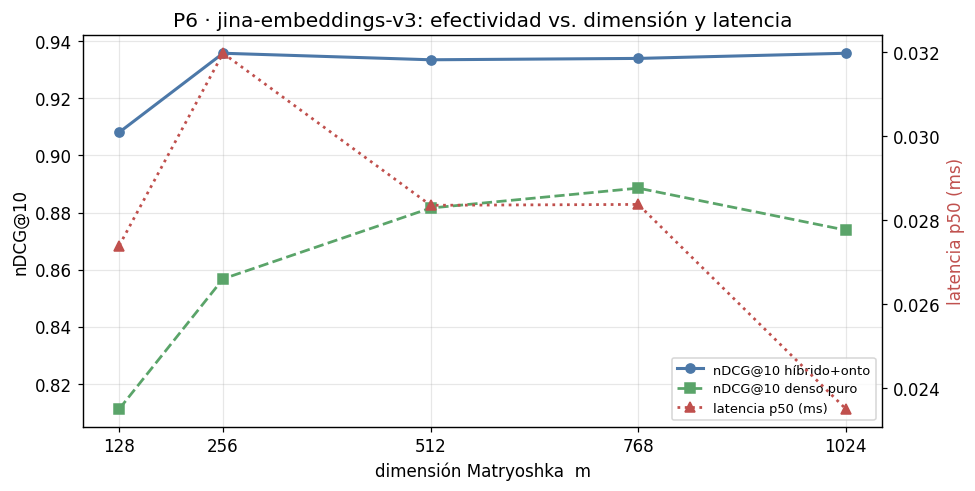

In [6]:
fig,ax1=plt.subplots(figsize=(9,4.6))
ax1.plot(df["dim"],df["ndcg@10 (híbrido+onto)"],"o-",color="#4c78a8",lw=2,label="nDCG@10 híbrido+onto")
ax1.plot(df["dim"],df["ndcg@10 (denso)"],"s--",color="#5aa469",lw=1.8,label="nDCG@10 denso puro")
ax1.set_xlabel("dimensión Matryoshka  m"); ax1.set_ylabel("nDCG@10"); ax1.set_xticks(df["dim"]); ax1.grid(alpha=0.3)
ax2=ax1.twinx(); ax2.plot(df["dim"],df["lat_p50_ms (híb+onto)"],"^:",color="#c0504d",lw=1.8,label="latencia p50 (ms)")
ax2.set_ylabel("latencia p50 (ms)",color="#c0504d")
l1,la1=ax1.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2,la1+la2,loc="lower right",fontsize=8.5)
ax1.set_title(f"P6 · {base.nombre}: efectividad vs. dimensión y latencia")
plt.tight_layout(); plt.show()

### 6.2 Memoria del índice denso

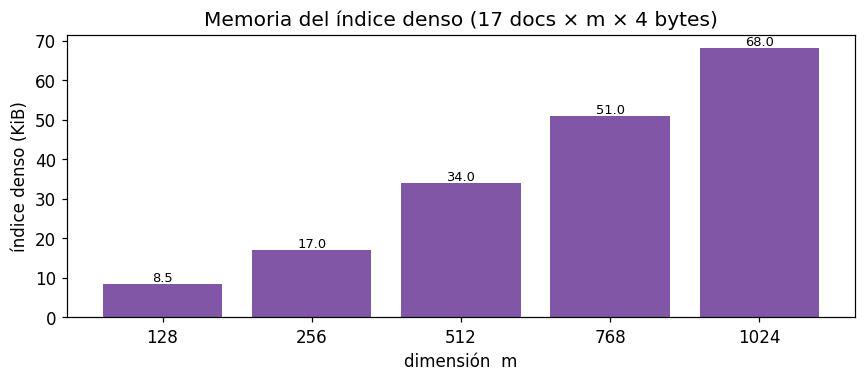

In [7]:
fig,ax=plt.subplots(figsize=(8,3.6))
ax.bar([str(d) for d in df["dim"]], df["índice_KiB"], color="#8156a7")
ax.set_xlabel("dimensión  m"); ax.set_ylabel("índice denso (KiB)")
for i,v in enumerate(df["índice_KiB"]): ax.text(i,v+max(df["índice_KiB"])*0.01,f"{v:.1f}",ha="center",fontsize=8.5)
ax.set_title(f"Memoria del índice denso ({len(docs)} docs × m × 4 bytes)")
plt.tight_layout(); plt.show()

**Interpretación de Resultados.** Con MRL, truncar mantiene una **alta retención** de
nDCG@10 en la configuración desplegable (híbrido+ontología) mientras el índice —lineal en
`m`— se reduce en la misma proporción. El **denso puro** es más sensible a `m`: la señal
léxica del híbrido amortigua la pérdida de dimensión. A esta escala la latencia está
dominada por la codificación de la consulta, no por el producto matriz-vector; el beneficio
principal de truncar es **memoria**, y crece al escalar el corpus.

## 7. Conclusión general — P6

- **Truncar es casi gratis en calidad** en la configuración desplegable: se puede bajar
  sustancialmente la dimensión con retención de nDCG@10 cercana a 1.0 y un ahorro de índice
  proporcional (ver §5).
- **El híbrido tolera mejor la compresión** que el denso puro → otra razón para preferir el
  híbrido en despliegues con memoria ajustada.
- **Recomendación operativa.** Elegir la menor `m` cuya retención supere el umbral tolerado
  (p. ej. ≥ 0.99 de la dimensión completa). El barrido de fragmento (P4) y el re-ranking se
  dejan como trabajo futuro con el corpus ampliado de la v2.

**Recordatorio.** El modelo está congelado; el truncado no es entrenamiento. Como en la
escalera, la lectura válida es **relativa** (dimensión vs. dimensión) bajo el mismo
protocolo *known-item*.